# Pair selection: correlation and cointegration

Select potential stock pairs using only the first 500 days:
1. correlation screen 
2. log-price cointegration 
3. FDR and half-life filters 
4. rolling stability
5. ranked research shortlist. 

This notebook stops at pair selection; it does not define a trading strategy.

In [38]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import coint

TRAIN_DAYS = 500
CORRELATION_FLOOR = 0.20
ROLLING_WINDOW = 250
ROLLING_STEP = 5

repo_root = Path.cwd()
if not (repo_root / 'backtester').exists():
    repo_root = repo_root.parent

prices_full = pd.read_csv(repo_root / 'backtester' / 'data' / '2026' / 'prices.txt', sep=r'\s+')
prices = prices_full.iloc[:TRAIN_DAYS].copy()
stock_tickers = prices.columns.drop('ALGO')
returns = prices.pct_change(fill_method=None)
stock_returns = returns[stock_tickers]
log_prices = np.log(prices[stock_tickers])

## 1. Correlation screen

Screen non-ALGO stock pairs by absolute daily-return correlation. The 0.20 floor is deliberately modest: it removes weakly related pairs without excluding potentially cointegrated pairs with only moderate same-day correlation.

In [39]:
return_correlation = stock_returns.corr()
upper_triangle = return_correlation.where(np.triu(np.ones(return_correlation.shape), k=1).astype(bool))
correlation_pairs = (
    upper_triangle.stack()
    .rename('return_correlation')
    .rename_axis(['ticker_a', 'ticker_b'])
    .reset_index()
    .assign(abs_return_correlation=lambda frame: frame['return_correlation'].abs())
    .sort_values('abs_return_correlation', ascending=False)
)
correlation_screen = correlation_pairs.query('abs_return_correlation >= @CORRELATION_FLOOR').copy()

print(f'{len(correlation_screen)} of {len(correlation_pairs)} stock pairs pass |correlation| ≥ {CORRELATION_FLOOR:.2f}.')
display(correlation_pairs.head(20).style.format({
    'return_correlation': '{:+.3f}',
    'abs_return_correlation': '{:.3f}',
}))

513 of 1225 stock pairs pass |correlation| ≥ 0.20.


,ticker_a,ticker_b,return_correlation,abs_return_correlation
586,CUBO,BENI,+0.463,0.463
1100,IHOZ,ILVX,+0.455,0.455
1192,BENI,ILVX,+0.445,0.445
135,SRNA,BENI,+0.438,0.438
1046,ACIX,ITPA,+0.437,0.437
884,RRES,NAYO,+0.413,0.413
521,MSDP,EAFC,+0.394,0.394
479,NPCK,ILVX,+0.393,0.393
400,DUCT,ILVX,+0.392,0.392
967,ACAC,ILVX,+0.391,0.391


**Notes / interpretation**

- This is only a screening table. High return correlation does not imply a stable price spread or a tradable mean-reversion relationship.
- The next test asks the more relevant question: whether a hedge-adjusted log-price spread is mean-reverting.

## 2. Cointegration on log prices

Run Engle–Granger tests only on the correlation-screened pairs. FDR-adjusted q-values control for the multiple tests remaining after screening.

In [40]:
rows = []
for row in correlation_screen.itertuples():
    ticker_a, ticker_b = row.ticker_a, row.ticker_b
    log_a, log_b = log_prices[ticker_a], log_prices[ticker_b]
    coint_statistic, p_value, _ = coint(log_a, log_b)
    hedge_beta, intercept = np.polyfit(log_b, log_a, 1)
    spread = log_a - (intercept + hedge_beta * log_b)
    delta_spread = spread.diff().dropna()
    lagged_spread = spread.shift(1).loc[delta_spread.index]
    mean_reversion_speed = np.polyfit(lagged_spread, delta_spread, 1)[0]
    half_life_days = -np.log(2) / mean_reversion_speed if mean_reversion_speed < 0 else np.inf
    rows.append({
        'ticker_a': ticker_a, 'ticker_b': ticker_b,
        'return_correlation': row.return_correlation,
        'coint_statistic': coint_statistic, 'p_value': p_value,
        'hedge_beta': hedge_beta, 'half_life_days': half_life_days,
    })

cointegration_results = pd.DataFrame(rows)
cointegration_results['fdr_q_value'] = multipletests(cointegration_results['p_value'], method='fdr_bh')[1]
cointegration_results = cointegration_results.sort_values(['fdr_q_value', 'p_value']).reset_index(drop=True)
display(cointegration_results.head(20).style.format({
    'return_correlation': '{:+.3f}', 'coint_statistic': '{:.3f}',
    'p_value': '{:.4g}', 'fdr_q_value': '{:.4g}',
    'hedge_beta': '{:.3f}', 'half_life_days': '{:.1f}',
}))

,ticker_a,ticker_b,return_correlation,coint_statistic,p_value,hedge_beta,half_life_days,fdr_q_value
0,SMAH,ILVX,+0.299,-5.959,1.99e-06,1.031,5.2,0.001021
1,AENO,NWIG,+0.253,-5.808,4.17e-06,0.982,4.1,0.00107
2,EORC,NGTE,+0.231,-5.691,7.299e-06,1.011,5.5,0.001248
3,HUXZ,ACAC,+0.250,-5.541,1.483e-05,1.020,6.0,0.001902
4,MHRM,EAFC,+0.375,-5.193,7.153e-05,0.941,6.7,0.007339
5,CTGI,EELT,+0.246,-5.118,9.934e-05,0.933,6.9,0.008493
6,ACIX,ITPA,+0.437,-4.656,0.0006702,0.967,8.4,0.04912
7,RTTH,NAYO,+0.225,-4.474,0.00135,0.845,10.2,0.08654
8,FWWG,BLBT,+0.374,-4.313,0.002445,0.912,9.6,0.1394
9,DUCT,NWIG,+0.238,-4.088,0.00536,0.868,10.4,0.275


## 3. FDR, half-life, and rolling-stability filters

Keep pairs with FDR q < 0.05, a positive 2–60 day half-life, cointegration in at least 80% of rolling windows, and a hedge-beta relative range no larger than 0.80.

In [41]:
def rolling_pair_metrics(ticker_a, ticker_b):
    hedge_betas, p_values = [], []
    for end in range(ROLLING_WINDOW, len(prices) + 1, ROLLING_STEP):
        log_a = log_prices[ticker_a].iloc[end - ROLLING_WINDOW:end]
        log_b = log_prices[ticker_b].iloc[end - ROLLING_WINDOW:end]
        hedge_betas.append(np.polyfit(log_b, log_a, 1)[0])
        p_values.append(coint(log_a, log_b)[1])
    beta_median = float(np.median(hedge_betas))
    beta_relative_range = float((max(hedge_betas) - min(hedge_betas)) / abs(beta_median))
    return {
        'rolling_coint_pass_pct': float(np.mean(np.asarray(p_values) < 0.05) * 100),
        'rolling_median_p_value': float(np.median(p_values)),
        'rolling_beta_min': float(min(hedge_betas)),
        'rolling_beta_max': float(max(hedge_betas)),
        'beta_relative_range': beta_relative_range,
    }

rolling_metrics = [
    rolling_pair_metrics(row.ticker_a, row.ticker_b)
    for row in cointegration_results.itertuples()
]
pair_evidence = pd.concat([cointegration_results, pd.DataFrame(rolling_metrics)], axis=1)
pair_evidence['passes_selection'] = (
    (pair_evidence['fdr_q_value'] < 0.05)
    & pair_evidence['half_life_days'].between(2, 60)
    & (pair_evidence['rolling_coint_pass_pct'] >= 80)
    & (pair_evidence['beta_relative_range'] <= 0.80)
)

display(pair_evidence.sort_values(['passes_selection', 'fdr_q_value'], ascending=[False, True]).head(20).style.format({
    'return_correlation': '{:+.3f}', 'fdr_q_value': '{:.4g}',
    'half_life_days': '{:.1f}', 'rolling_coint_pass_pct': '{:.0f}%',
    'rolling_median_p_value': '{:.3f}', 'rolling_beta_min': '{:.2f}',
    'rolling_beta_max': '{:.2f}', 'beta_relative_range': '{:.2f}',
}))

,ticker_a,ticker_b,return_correlation,coint_statistic,p_value,hedge_beta,half_life_days,fdr_q_value,rolling_coint_pass_pct,rolling_median_p_value,rolling_beta_min,rolling_beta_max,beta_relative_range,passes_selection
0,SMAH,ILVX,+0.299,-5.958952,0.000002,1.031074,5.2,0.001021,94%,0.007,0.87,1.12,0.24,True
1,AENO,NWIG,+0.253,-5.807732,0.000004,0.981604,4.1,0.00107,100%,0.000,0.70,0.96,0.28,True
2,EORC,NGTE,+0.231,-5.691226,0.000007,1.011208,5.5,0.001248,92%,0.008,0.87,1.03,0.17,True
3,HUXZ,ACAC,+0.250,-5.540789,0.000015,1.020139,6.0,0.001902,92%,0.008,0.82,1.04,0.23,True
4,MHRM,EAFC,+0.375,-5.193248,0.000072,0.941036,6.7,0.007339,84%,0.009,0.52,1.09,0.74,True
5,CTGI,EELT,+0.246,-5.117972,0.000099,0.933326,6.9,0.008493,80%,0.029,0.74,0.97,0.26,True
6,ACIX,ITPA,+0.437,-4.656256,0.000670,0.967296,8.4,0.04912,67%,0.019,0.83,1.41,0.52,False
7,RTTH,NAYO,+0.225,-4.474258,0.001350,0.845385,10.2,0.08654,76%,0.002,0.43,0.82,0.60,False
8,FWWG,BLBT,+0.374,-4.312823,0.002445,0.911868,9.6,0.1394,31%,0.071,0.24,1.07,0.92,False
9,DUCT,NWIG,+0.238,-4.087876,0.005360,0.867591,10.4,0.275,61%,0.036,0.76,1.12,0.40,False


## 4. Rolling evidence for shortlisted pairs

Each figure shows the 250-day rolling hedge beta and Engle–Granger p-value for a pair that passes every selection filter.

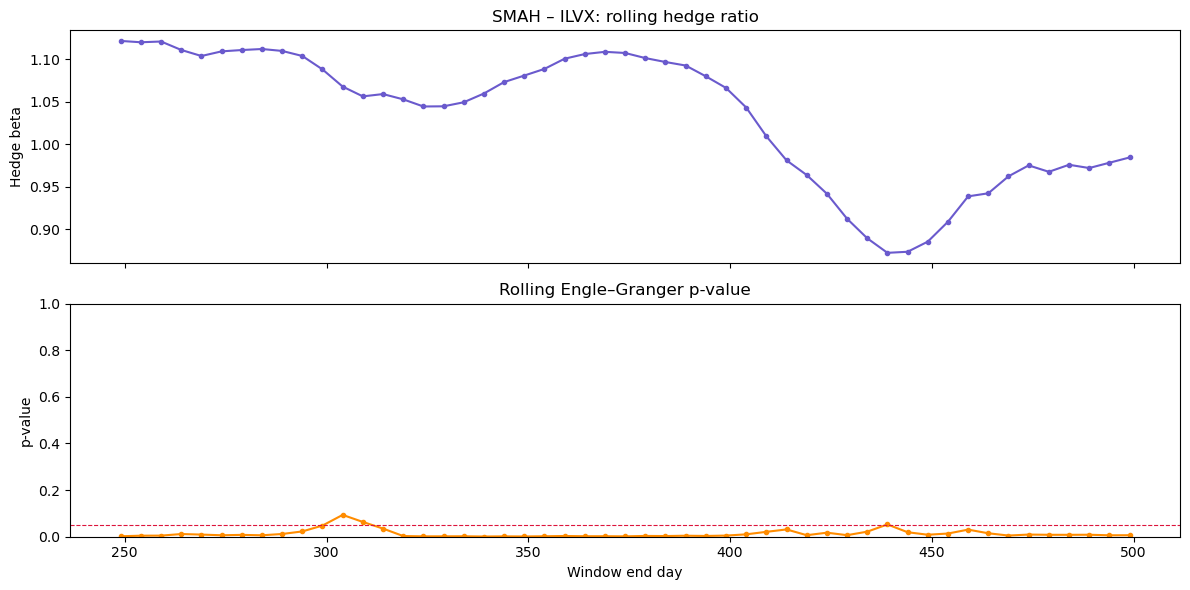

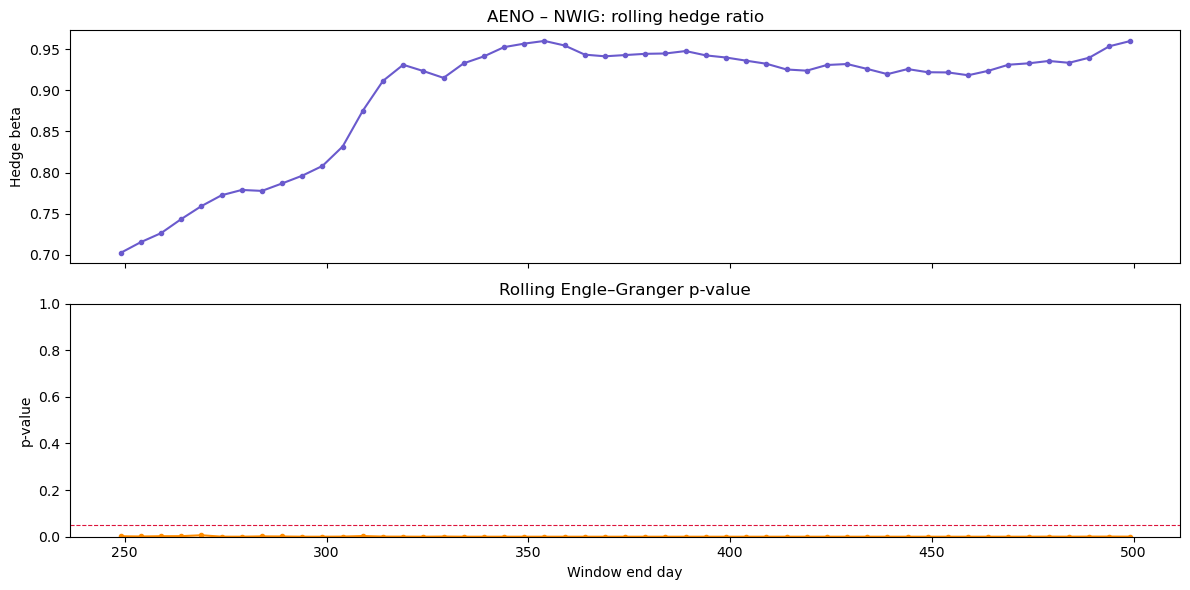

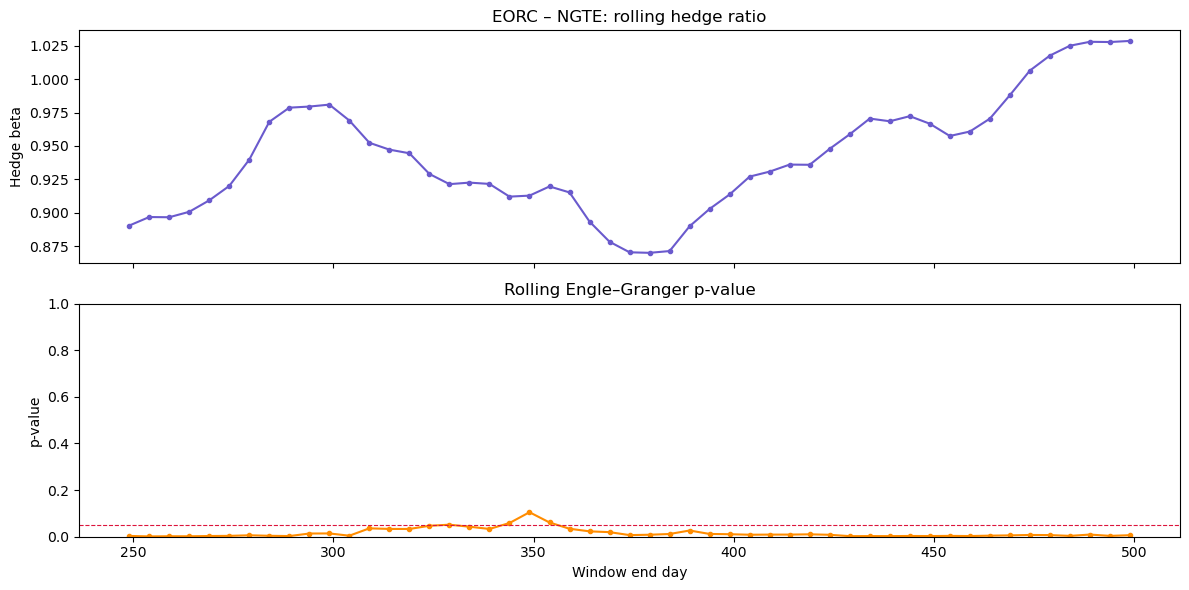

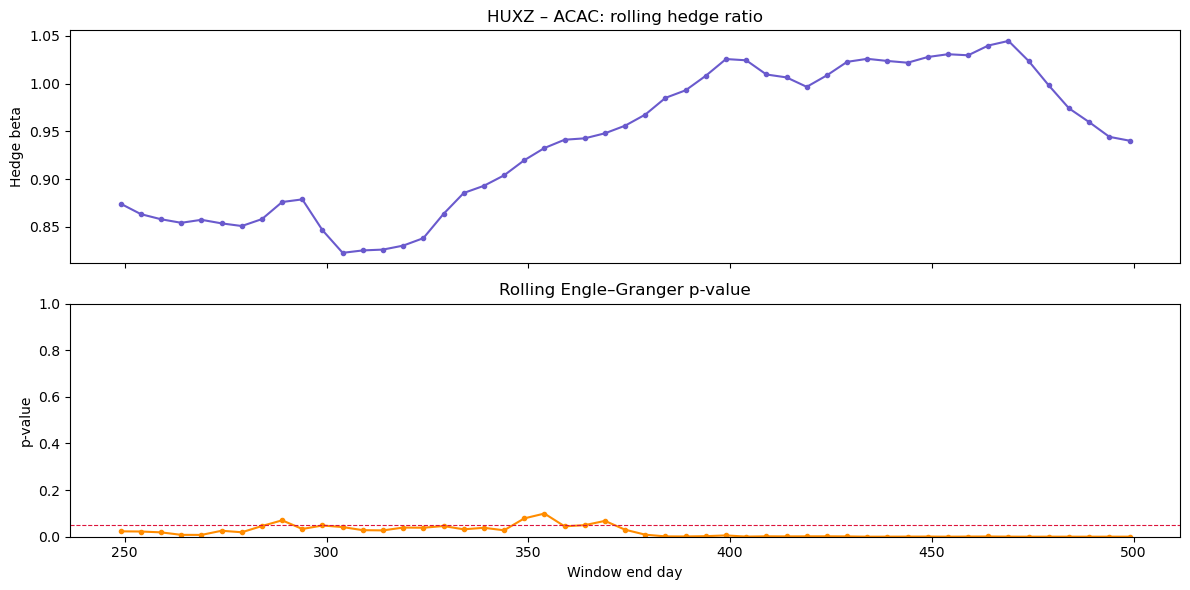

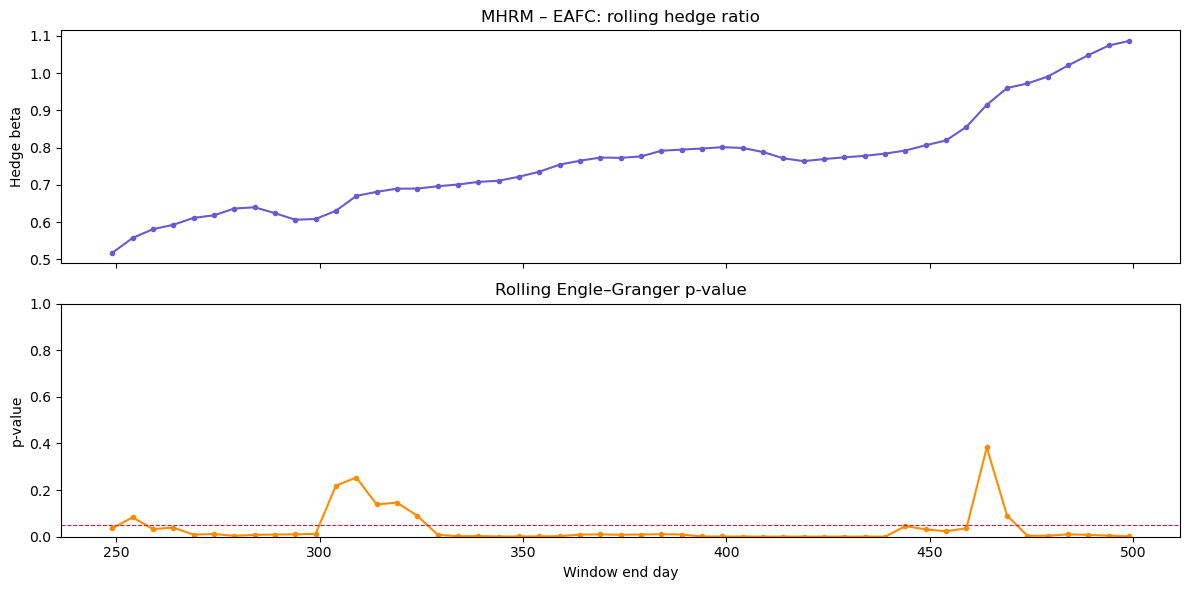

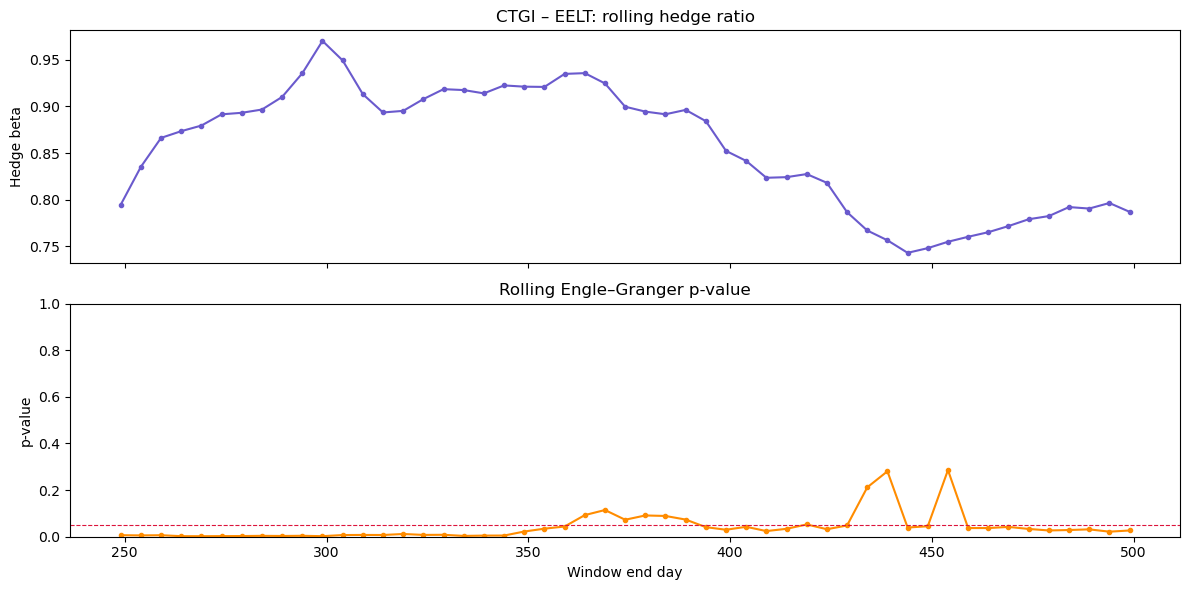

In [42]:
shortlisted_pairs = pair_evidence.query('passes_selection').copy()

for row in shortlisted_pairs.itertuples():
    ticker_a, ticker_b = row.ticker_a, row.ticker_b
    ends, hedge_betas, p_values = [], [], []
    for end in range(ROLLING_WINDOW, len(prices) + 1, ROLLING_STEP):
        log_a = log_prices[ticker_a].iloc[end - ROLLING_WINDOW:end]
        log_b = log_prices[ticker_b].iloc[end - ROLLING_WINDOW:end]
        ends.append(end - 1)
        hedge_betas.append(np.polyfit(log_b, log_a, 1)[0])
        p_values.append(coint(log_a, log_b)[1])
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(ends, hedge_betas, marker='o', markersize=3, color='slateblue')
    axes[0].set(title=f'{ticker_a} – {ticker_b}: rolling hedge ratio', ylabel='Hedge beta')
    axes[1].plot(ends, p_values, marker='o', markersize=3, color='darkorange')
    axes[1].axhline(0.05, color='crimson', linewidth=0.8, linestyle='--')
    axes[1].set(title='Rolling Engle–Granger p-value', xlabel='Window end day', ylabel='p-value', ylim=(0, 1))
    plt.tight_layout()
    plt.show()

## 5. Draft pair choices

Rank the shortlisted pairs by lower FDR q-value, higher rolling cointegration pass rate, and lower hedge-beta instability. These are research choices only—not approved strategies.

In [43]:
draft_pair_choices = shortlisted_pairs.sort_values(
    ['fdr_q_value', 'rolling_coint_pass_pct', 'beta_relative_range'],
    ascending=[True, False, True],
).reset_index(drop=True)
draft_pair_choices.index = draft_pair_choices.index + 1

display(draft_pair_choices[[
    'ticker_a', 'ticker_b', 'return_correlation', 'fdr_q_value',
    'half_life_days', 'rolling_coint_pass_pct',
    'rolling_beta_min', 'rolling_beta_max', 'beta_relative_range',
]].style.format({
    'return_correlation': '{:+.3f}', 'fdr_q_value': '{:.4g}',
    'half_life_days': '{:.1f}', 'rolling_coint_pass_pct': '{:.0f}%',
    'rolling_beta_min': '{:.2f}', 'rolling_beta_max': '{:.2f}',
    'beta_relative_range': '{:.2f}',
}))

,ticker_a,ticker_b,return_correlation,fdr_q_value,half_life_days,rolling_coint_pass_pct,rolling_beta_min,rolling_beta_max,beta_relative_range
1,SMAH,ILVX,+0.299,0.001021,5.2,94%,0.87,1.12,0.24
2,AENO,NWIG,+0.253,0.00107,4.1,100%,0.70,0.96,0.28
3,EORC,NGTE,+0.231,0.001248,5.5,92%,0.87,1.03,0.17
4,HUXZ,ACAC,+0.250,0.001902,6.0,92%,0.82,1.04,0.23
5,MHRM,EAFC,+0.375,0.007339,6.7,84%,0.52,1.09,0.74
6,CTGI,EELT,+0.246,0.008493,6.9,80%,0.74,0.97,0.26


**Notes / interpretation**

- Treat this table as a ranked research shortlist, not an automatic selection. The filters reduce fragile pairs but cannot guarantee future mean reversion.
- Do not use the holdout period (days 501–750) to adjust this ranking.